# Project Objective 

#### The goal of this project was to analyze bike-sharing data and build machine learning models capable of predicting bike rental demand based on factors such as weather conditions, season, temperature, humidity, working days, and hourly usage patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
dataset = pd.read_csv('hour.csv')

In [3]:
dataset.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [5]:
dataset.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [6]:
dataset.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [7]:
dataset.shape

(17379, 17)

In [8]:
dataset.duplicated().sum()

np.int64(0)

In [9]:
dataset['cnt'].describe()

count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64

## EDA

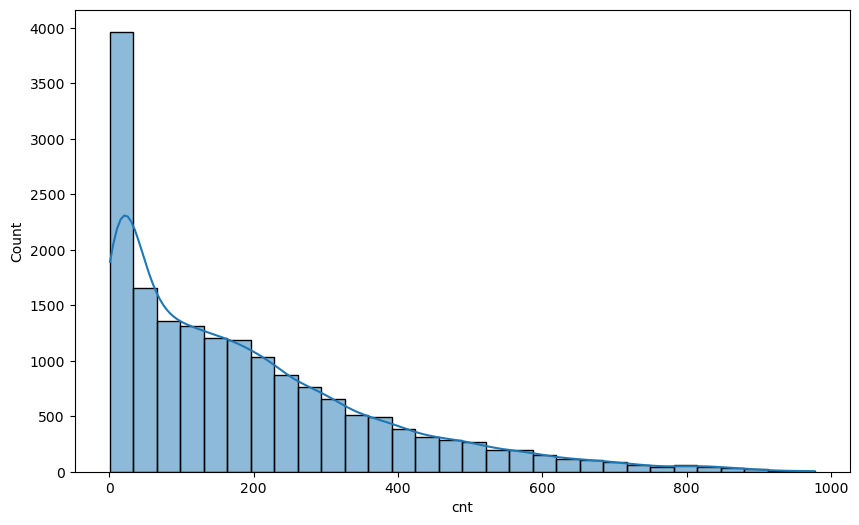

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(dataset['cnt'], bins=30, kde=True)
plt.show()

In [11]:
corr = dataset.corr(numeric_only=True)

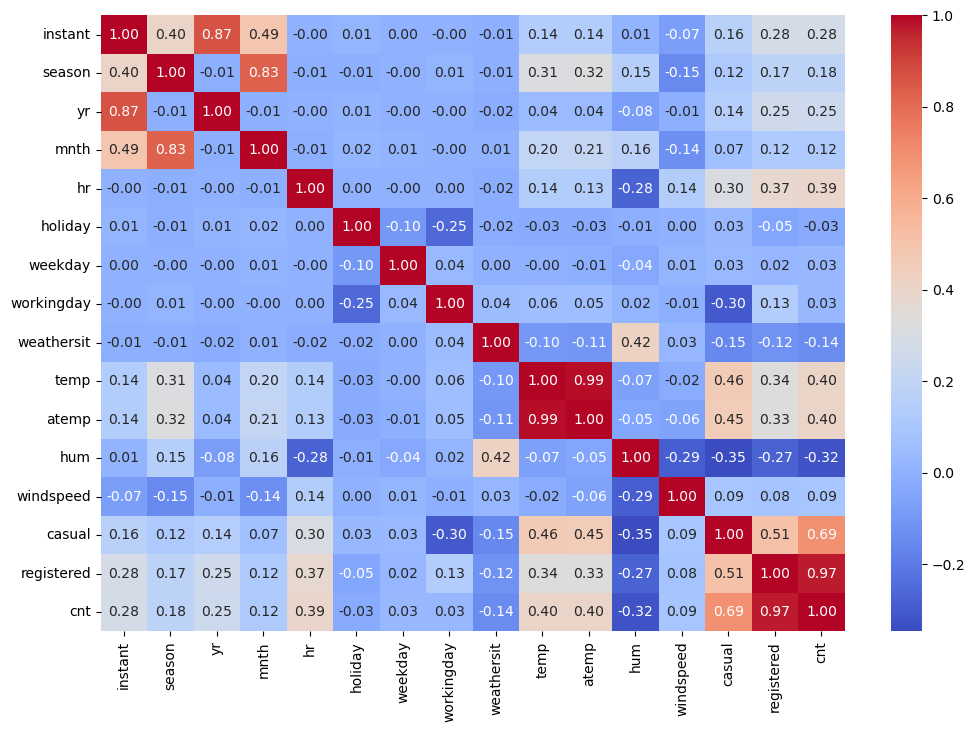

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

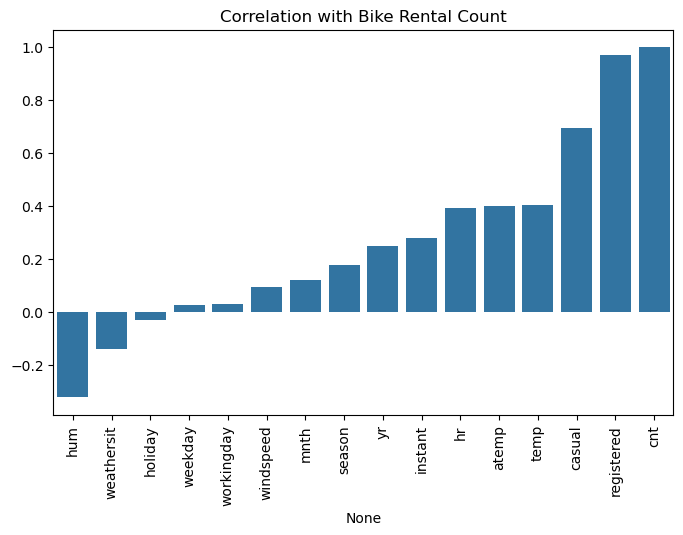

In [13]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=dataset.corr(numeric_only=True)['cnt'].sort_values().index,
    y=dataset.corr(numeric_only=True)['cnt'].sort_values().values
)

plt.xticks(rotation=90)
plt.title("Correlation with Bike Rental Count")
plt.show()

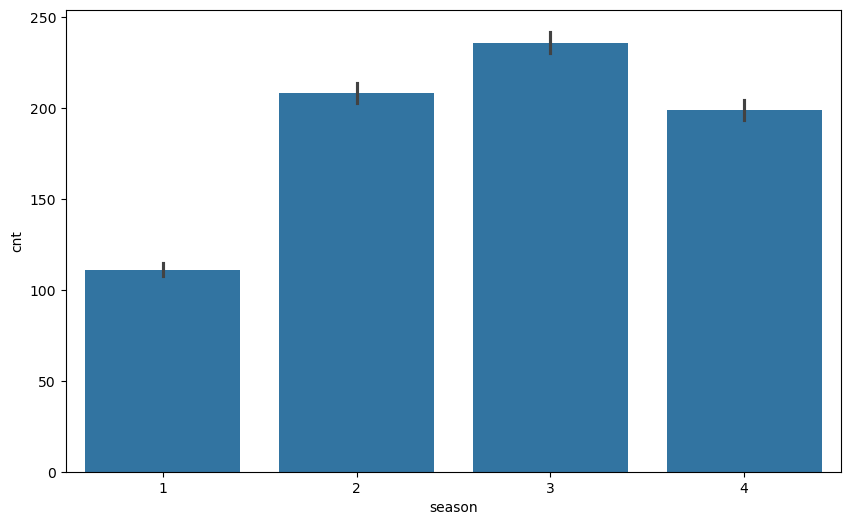

In [14]:
# EDA on day dataset
plt.figure(figsize=(10,6))
sns.barplot(x=dataset['season'], y=dataset['cnt'])
plt.show()

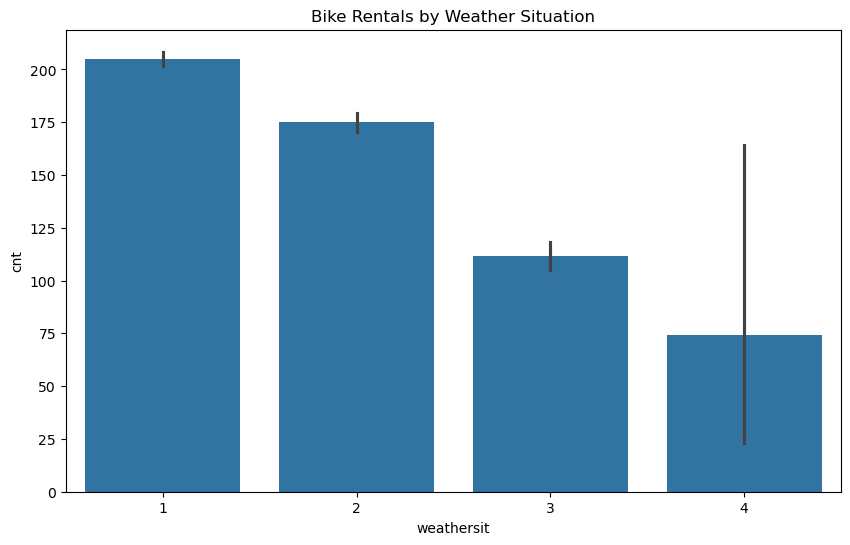

In [15]:
plt.figure(figsize=(10,6))
sns.barplot(x=dataset['weathersit'], y=dataset['cnt'])
plt.title("Bike Rentals by Weather Situation")
plt.show()

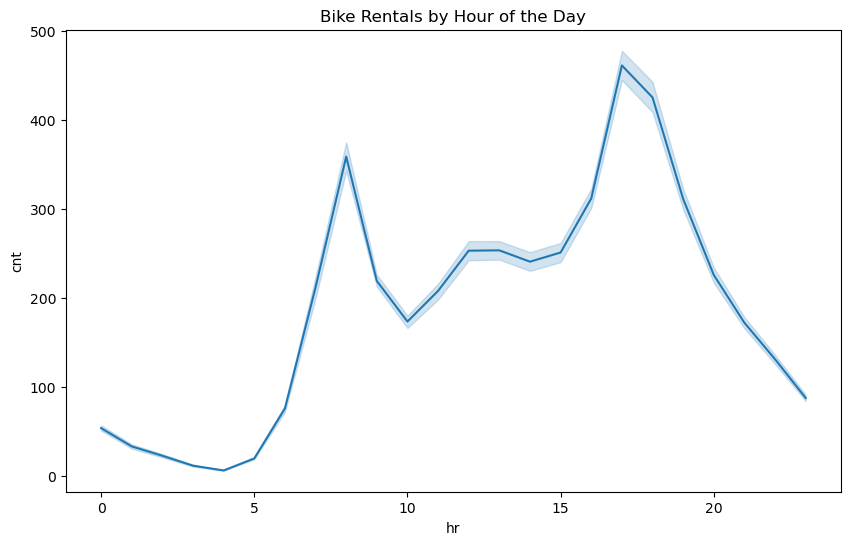

In [16]:
plt.figure(figsize=(10,6))
sns.lineplot(x=dataset['hr'], y=dataset['cnt'])
plt.title("Bike Rentals by Hour of the Day")
plt.show()

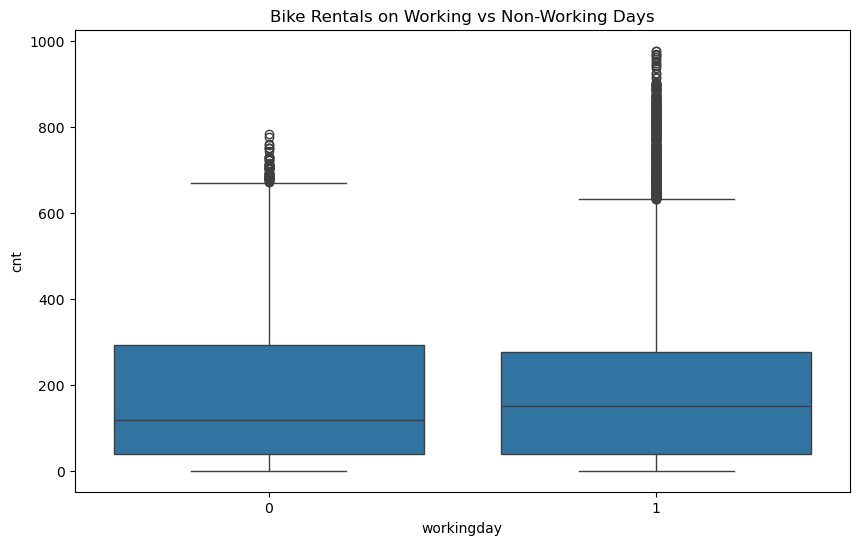

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(x=dataset['workingday'], y=dataset['cnt'])
plt.title("Bike Rentals on Working vs Non-Working Days")
plt.show()

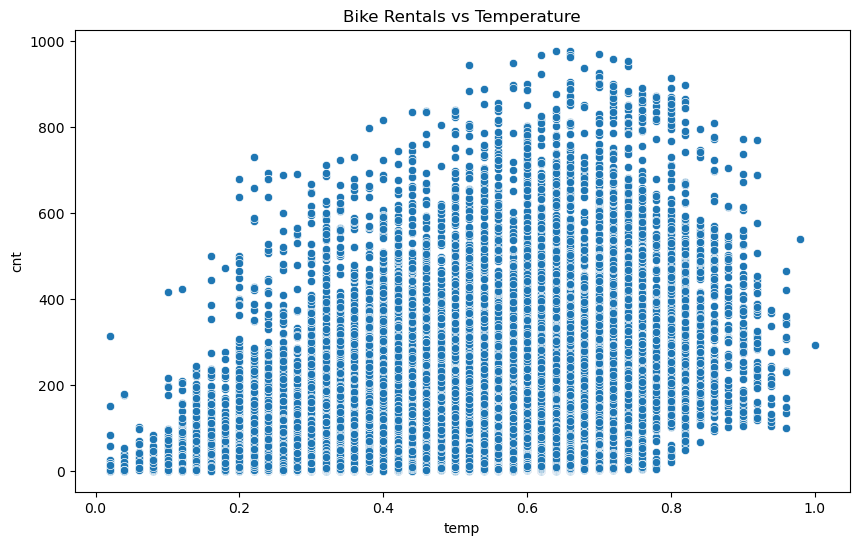

In [18]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=dataset['temp'], y=dataset['cnt'])
plt.title("Bike Rentals vs Temperature")
plt.show()

In [19]:
dataset.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [20]:
dta = dataset[['casual','registered','cnt']]
dta.head()

,casual,registered,cnt
0,3,13,16
1,8,32,40
2,5,27,32
3,3,10,13
4,0,1,1


In [21]:
df_model = dataset.drop(['instant','dteday','casual','registered'], axis=1)
df_model.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [22]:
x = df_model.drop('cnt', axis=1)
y = df_model['cnt']

In [23]:
#train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(13903, 12)
(3476, 12)
(13903,)
(3476,)


## Linear Regression

#### Performed poorly with high error and low R² score, indicating inability to capture complex relationships in the data.

In [24]:
#linear regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [25]:
y_pred = lr.predict(x_test)
y_pred

array([450.29652451, 204.67414527,  57.29789092, ...,  45.54126275,
       190.38936951, 215.37309383])

In [26]:
compare = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
compare.head()

,Actual,Predicted
12830,425,450.296525
8688,88,204.674145
7091,4,57.297891
12230,526,383.363764
431,13,-20.341232


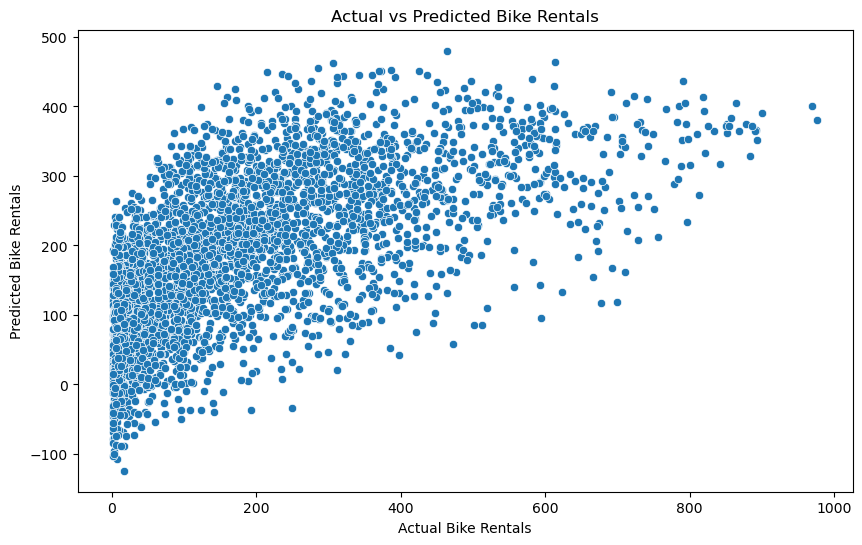

In [27]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Bike Rentals")
plt.ylabel("Predicted Bike Rentals")
plt.title("Actual vs Predicted Bike Rentals")
plt.show()

In [28]:
dataset['cnt'].describe()

count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64

### Model Evaluation

In [29]:
# Model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [30]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 104.80335089554424


In [31]:
mse  =  mean_squared_error(y_test, y_pred)
mse

19379.828367651728

In [32]:
rmse  =  np.sqrt(mse)   
rmse

np.float64(139.2114519989348)

In [33]:
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

R-squared: 0.3879811583139132


## Decision tree regression

#### Significantly improved prediction accuracy and captured non-linear patterns better.

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(x_train, y_train)

DecisionTreeRegressor(random_state=42)

In [51]:
dt_pred = dt.predict(x_test)
dt_pred

array([360.,  90.,  12., ...,  78., 434., 251.])

In [52]:
dt_mae = mean_absolute_error(y_test, dt_pred)
print("Decision Tree Mean Absolute Error:", dt_mae)

dt_mse = mean_squared_error(y_test, dt_pred)
print("Decision Tree Mean Squared Error:", dt_mse)

dt_rmse = np.sqrt(dt_mse)
print("Decision Tree Root Mean Squared Error:", dt_rmse)

dt_r2 = r2_score(y_test, dt_pred)
print("Decision Tree R-squared:", dt_r2)

Decision Tree Mean Absolute Error: 34.1800920598389
Decision Tree Mean Squared Error: 3392.90333716916
Decision Tree Root Mean Squared Error: 58.24863377942147
Decision Tree R-squared: 0.8928514365053305


## Random forest regressor

#### Achieved strong performance with low error metrics and high R² score.

In [35]:
# random forest regressor
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [36]:
rf_pred =  rf.predict(x_test)
rf_pred

array([380.69,  95.65,  11.92, ...,  81.34, 365.29, 243.43])

In [37]:
rf_mae = mean_absolute_error(y_test, rf_pred)
print("Random Forest Mean Absolute Error:", rf_mae)

Random Forest Mean Absolute Error: 24.902861502685077


In [38]:
rf_mse  =  mean_squared_error(y_test, rf_pred)
print("Random Forest Mean Squared Error:", rf_mse)

Random Forest Mean Squared Error: 1769.8364453122304


In [39]:
rf_rmse =  np.sqrt(rf_mse)
print("Random Forest Root Mean Squared Error:", rf_rmse)

Random Forest Root Mean Squared Error: 42.06942411434022


In [40]:
rf_r2 = r2_score(y_test, rf_pred)
print("Random Forest R-squared:", rf_r2)

Random Forest R-squared: 0.9441082123801563


## Xgboost regressor

#### Delivered the best overall performance among all models.

In [41]:
#xgboost regressor
from xgboost import XGBRegressor
xgb = XGBRegressor(random_state=42)
xgb.fit(x_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [42]:
xgb_pred = xgb.predict(x_test)
xgb_pred

array([382.24615 , 124.278946,   8.667156, ...,  73.14348 , 359.1021  ,
       233.36246 ], dtype=float32)

In [43]:
xgb_mse  =  mean_squared_error(y_test, xgb_pred)    
print("XGBoost Mean Squared Error:", xgb_mse)

XGBoost Mean Squared Error: 1619.3082275390625


In [44]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
print("XGBoost Mean Absolute Error:", xgb_mae)  

XGBoost Mean Absolute Error: 25.00953483581543


In [45]:
xgb_rmse = np.sqrt(xgb_mse)
print("XGBoost Root Mean Squared Error:", xgb_rmse)

XGBoost Root Mean Squared Error: 40.240629064902336


In [46]:
xgb_r2 = r2_score(y_test, xgb_pred)
print("XGBoost R-squared:", xgb_r2)

XGBoost R-squared: 0.9488619565963745


In [47]:
# Feature importance 
importances =  pd.DataFrame({'Feature': x.columns, 'Importance': xgb.feature_importances_})
importances.sort_values(by='Importance', ascending=False, inplace=True)
importances

,Feature,Importance
6,workingday,0.324430
3,hr,0.217045
1,yr,0.176259
8,temp,0.086829
0,season,0.057121
7,weathersit,0.046941
9,atemp,0.044336
5,weekday,0.012246
2,mnth,0.011132
10,hum,0.009985


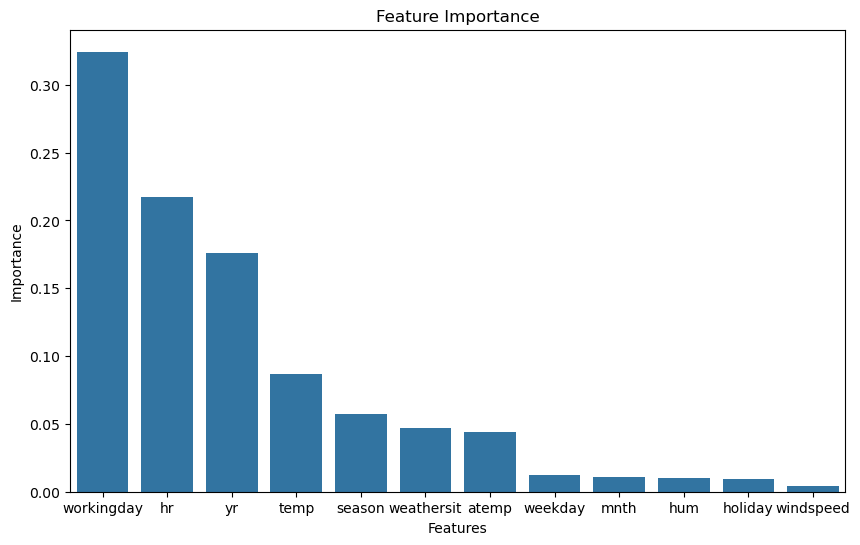

In [48]:
plt.figure(figsize=(10,6))
sns.barplot(x=importances['Feature'], y=importances['Importance'])
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()

In [54]:
compare_models = pd.DataFrame({
    'Model': ['Linear Regression','Decision Tree', 'Random Forest', 'XGBoost'],
    'MAE': [mae,dt_mae, rf_mae, xgb_mae],
    'MSE': [mse,dt_mse, rf_mse, xgb_mse],
    'RMSE': [rmse,dt_rmse, rf_rmse, xgb_rmse],
    'R-squared': [r2,dt_r2, rf_r2, xgb_r2]
})
compare_models


,Model,MAE,MSE,RMSE,R-squared
0,Linear Regression,104.803351,19379.828368,139.211452,0.387981
1,Decision Tree,34.180092,3392.903337,58.248634,0.892851
2,Random Forest,24.902862,1769.836445,42.069424,0.944108
3,XGBoost,25.009535,1619.308228,40.240629,0.948862


## Testing the model with sample data

In [50]:
sample_data = [[
    3,      # season
    1,      # yr
    7,      # mnth
    8,      # hr
    0,      # holiday
    1,      # weekday
    1,      # workingday
    1,      # weathersit
    0.70,   # temp
    0.65,   # atemp
    0.50,   # hum
    0.20    # windspeed
]]
prediction = xgb.predict(sample_data)
print("Predicted Bike Rentals:", prediction[0])

Predicted Bike Rentals: 640.5091


## Conclusion:

#### The project successfully demonstrated how machine learning can be used to predict bike rental demand with high accuracy. Among all tested models, XGBoost provided the best results due to its ability to learn complex non-linear relationships and feature interactions.